# 🌍 Hybrid AQI Model with Seasonal Features and Prior Split
---
## Architecture
```
[Raw Data] → [Preprocessing] → [SARIMA] → [Feature Fusion] → [XGBoost] → [SHAP] → [Final Prediction + Explanation]
```

**Pipeline Overview:**
1. **Step Import & Setup** — Load required libraries and configure reproducibility.
2. **City Selection & Cleaning** — Select the city with valid AQI coverage and clean features safely.
3. **Seasonal Feature Engineering** — Create lag, rolling, and cyclical calendar features.
4. **SARIMA Seasonal Model** — Capture temporal seasonality from the train period.
5. **Hybrid Feature Fusion** — Inject SARIMA predictions into XGBoost features.
6. **Modeling & Explanation** — Train standalone and hybrid XGBoost, compare metrics, and explain with SHAP.

## 0. Install Dependencies
Run this cell once to install required packages in the current notebook kernel.

In [ ]:
import subprocess, sys
packages = ['statsmodels', 'xgboost', 'shap', 'seaborn', 'scikit-learn']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('All dependencies installed successfully.')

## 1. Imports and Data Loading

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option('display.max_columns', 200)

df_raw = pd.read_csv('Dataset.csv')
df_raw = df_raw.rename(columns={'City': 'city', 'Date': 'date'})
df_raw['date'] = pd.to_datetime(df_raw['date'])

print('Rows:', len(df_raw))
print('Columns:', list(df_raw.columns))
print('Cities:', df_raw['city'].dropna().unique()[:10])

Rows: 29531
Columns: ['city', 'date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']
Cities: <StringArray>
[   'Ahmedabad',       'Aizawl',    'Amaravati',     'Amritsar',
    'Bengaluru',       'Bhopal', 'Brajrajnagar',   'Chandigarh',
      'Chennai',   'Coimbatore']
Length: 10, dtype: str


## 2. City Selection and Cleaning

In [10]:
aqi_counts = df_raw.groupby('city')['AQI'].apply(lambda s: s.notna().sum()).sort_values(ascending=False)
CITY = 'Ahmedabad'
if CITY not in aqi_counts.index or aqi_counts.get(CITY, 0) == 0:
    CITY = aqi_counts.index[0]

df = df_raw[df_raw['city'] == CITY].copy().sort_values('date').set_index('date')

target = 'AQI'
pollutants = [c for c in ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3'] if c in df.columns]
weather = [c for c in ['t2m', 'd2m', 'sp', 'blh', 'u10', 'v10'] if c in df.columns]
base_cols = pollutants + weather + [target]
df = df[base_cols].copy()

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

feature_fill_cols = [c for c in df.columns if c != target]
df[feature_fill_cols] = df[feature_fill_cols].ffill().bfill()
df[feature_fill_cols] = df[feature_fill_cols].fillna(0)
df = df.dropna(subset=[target]).copy()
df = df.asfreq('D')
df[feature_fill_cols] = df[feature_fill_cols].ffill().bfill().fillna(0)
df = df.dropna(subset=[target]).copy()

print('City:', CITY)
print('Available AQI rows for city:', int(aqi_counts.get(CITY, 0)))
print('Rows after cleaning:', len(df))
print('Missing values:', int(df.isna().sum().sum()))
df.head()

City: Ahmedabad
Available AQI rows for city: 1334
Rows after cleaning: 1334
Missing values: 0


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI
date,,,,,,,,,,
2015-01-29,83.13,141.54,6.93,28.71,33.72,0.0,6.93,49.52,59.76,209.0
2015-01-30,79.84,141.54,13.85,28.68,41.08,0.0,13.85,48.49,97.07,328.0
2015-01-31,94.52,141.54,24.39,32.66,52.61,0.0,24.39,67.39,111.33,514.0
2015-02-01,135.99,141.54,43.48,42.08,84.57,0.0,43.48,75.23,102.70,782.0
2015-02-02,178.33,141.54,54.56,35.31,72.80,0.0,54.56,55.04,107.38,914.0


## 3. Seasonal Feature Engineering

In [11]:
for lag in [1, 2, 3, 7, 14, 21, 28]:
    df[f'AQI_lag_{lag}'] = df[target].shift(lag)

for window in [7, 14, 30]:
    shifted = df[target].shift(1)
    df[f'AQI_roll_{window}_mean'] = shifted.rolling(window).mean()
    df[f'AQI_roll_{window}_std'] = shifted.rolling(window).std()
    df[f'AQI_roll_{window}_min'] = shifted.rolling(window).min()
    df[f'AQI_roll_{window}_max'] = shifted.rolling(window).max()

df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['day_of_year'] = df.index.dayofyear
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df = df.dropna().copy()
feature_cols = [c for c in df.columns if c != target]
X = df[feature_cols].copy()
y = df[target].copy()

print('Feature count:', len(feature_cols))
print('Final rows:', len(df))
X.head()

Feature count: 36
Final rows: 1304


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI_lag_1,AQI_lag_2,AQI_lag_3,AQI_lag_7,AQI_lag_14,AQI_lag_21,AQI_lag_28,AQI_roll_7_mean,AQI_roll_7_std,AQI_roll_7_min,AQI_roll_7_max,AQI_roll_14_mean,AQI_roll_14_std,AQI_roll_14_min,AQI_roll_14_max,AQI_roll_30_mean,AQI_roll_30_std,AQI_roll_30_min,AQI_roll_30_max,day_of_week,month,day_of_year,is_weekend,dow_sin,dow_cos,month_sin,month_cos
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-03-04,93.88,141.54,18.21,29.38,47.01,0.0,18.21,62.75,46.79,408.0,189.0,292.0,1141.0,761.0,247.0,514.0,622.428571,418.110774,189.0,1247.0,586.785714,296.180345,189.0,1247.0,488.800000,270.111778,149.0,1247.0,2,3,63,0,0.974928,-0.222521,1.0,6.123234e-17
2015-03-05,173.01,141.54,48.44,42.27,90.73,0.0,48.44,78.76,59.39,383.0,408.0,189.0,669.0,475.0,379.0,782.0,514.142857,354.783703,189.0,1247.0,559.785714,296.306540,189.0,1247.0,494.600000,265.729134,149.0,1247.0,3,3,64,0,0.433884,-0.900969,1.0,6.123234e-17
2015-03-08,71.56,141.54,3.51,16.83,20.32,0.0,3.51,30.28,57.16,780.0,383.0,408.0,1247.0,536.0,341.0,914.0,530.000000,365.186710,189.0,1247.0,581.571429,300.772010,189.0,1247.0,509.666667,268.754129,149.0,1247.0,6,3,67,1,-0.781831,0.623490,1.0,6.123234e-17
2015-03-09,119.80,141.54,4.13,24.07,27.90,0.0,4.13,50.35,50.49,190.0,780.0,383.0,411.0,479.0,256.0,660.0,379.000000,200.861478,189.0,780.0,556.857143,318.497641,189.0,1247.0,498.866667,275.011189,149.0,1247.0,0,3,68,0,0.000000,1.000000,1.0,6.123234e-17
2015-03-10,106.71,141.54,5.39,25.59,30.51,0.0,5.39,38.85,60.17,233.0,190.0,780.0,292.0,592.0,388.0,294.0,353.571429,207.299186,189.0,780.0,539.285714,329.711862,189.0,1247.0,480.566667,273.784295,149.0,1247.0,1,3,69,0,0.781831,0.623490,1.0,6.123234e-17


## 4. Train-Test Split

In [12]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()
y_train = train_df[target].copy()
y_test = test_df[target].copy()

print('Train rows:', len(X_train))
print('Test rows :', len(X_test))
print('Train range:', train_df.index.min(), 'to', train_df.index.max())
print('Test range :', test_df.index.min(), 'to', test_df.index.max())

Train rows: 1043
Test rows : 261
Train range: 2015-03-04 00:00:00 to 2019-10-06 00:00:00
Test range : 2019-10-07 00:00:00 to 2020-07-01 00:00:00


## 5. SARIMA Seasonal Model

In [13]:
SARIMA_ORDER = (1, 1, 1)
SEASONAL_ORDER = (1, 1, 1, 7)

print(f'Fitting SARIMA{SARIMA_ORDER}x{SEASONAL_ORDER} on train data...')
sarima_model = SARIMAX(
    y_train,
    order=SARIMA_ORDER,
    seasonal_order=SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False, maxiter=200)
print(sarima_fit.summary().tables[0])
print(sarima_fit.summary().tables[1])

sarima_pred_train = sarima_fit.fittedvalues
sarima_pred_test = sarima_fit.forecast(steps=len(test_df))
sarima_pred_test.index = test_df.index

sarima_mae = mean_absolute_error(y_test, sarima_pred_test)
sarima_rmse = np.sqrt(mean_squared_error(y_test, sarima_pred_test))
sarima_mape = np.mean(np.abs(y_test.values - sarima_pred_test.values) / np.clip(np.abs(y_test.values), 1e-8, None)) * 100
sarima_r2 = r2_score(y_test, sarima_pred_test)

print(f'SARIMA MAE : {sarima_mae:.3f}')
print(f'SARIMA RMSE: {sarima_rmse:.3f}')
print(f'SARIMA MAPE: {sarima_mape:.2f}%')
print(f'SARIMA R^2 : {sarima_r2:.4f}')

Fitting SARIMA(1, 1, 1)x(1, 1, 1, 7) on train data...


c:\Users\piyus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\piyus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                               AQI   No. Observations:                 1043
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -7028.241
Date:                           Sat, 11 Apr 2026   AIC                          14066.483
Time:                                   22:49:12   BIC                          14091.150
Sample:                                        0   HQIC                         14075.846
                                          - 1043                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4918      0.021     22.902      0.000       0.450       0.534
ma.L1         -0.9419      0.010    -95.079

c:\Users\piyus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\piyus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## 6. Hybrid Feature Fusion

In [14]:
train_df = train_df.copy()
test_df = test_df.copy()
train_df['SARIMA_pred'] = sarima_pred_train.reindex(train_df.index)
test_df['SARIMA_pred'] = sarima_pred_test

train_df['SARIMA_pred'] = train_df['SARIMA_pred'].ffill().bfill()
test_df['SARIMA_pred'] = test_df['SARIMA_pred'].ffill().bfill()

hybrid_feature_cols = [c for c in train_df.columns if c != target]
X_train_hybrid = train_df[hybrid_feature_cols].copy()
X_test_hybrid = test_df[hybrid_feature_cols].copy()

print('Hybrid feature count:', len(hybrid_feature_cols))
print('SARIMA_pred included:', 'SARIMA_pred' in hybrid_feature_cols)

Hybrid feature count: 37
SARIMA_pred included: True


## 7. XGBoost Models

In [15]:
xgb_only_model = xgb.XGBRegressor(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=2,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    objective='reg:squarederror'
)
xgb_only_model.fit(X_train, y_train, verbose=False)
xgb_only_pred = xgb_only_model.predict(X_test)

hybrid_model = xgb.XGBRegressor(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=2,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    objective='reg:squarederror'
)
hybrid_model.fit(X_train_hybrid, y_train, verbose=False)
hybrid_pred = hybrid_model.predict(X_test_hybrid)

def safe_mape(actual, predicted):
    denom = np.clip(np.abs(actual), 1e-8, None)
    return np.mean(np.abs(actual - predicted) / denom) * 100

xgb_only_mae = mean_absolute_error(y_test, xgb_only_pred)
xgb_only_rmse = np.sqrt(mean_squared_error(y_test, xgb_only_pred))
xgb_only_r2 = r2_score(y_test, xgb_only_pred)
xgb_only_mape = safe_mape(y_test.values, xgb_only_pred)

hybrid_mae = mean_absolute_error(y_test, hybrid_pred)
hybrid_rmse = np.sqrt(mean_squared_error(y_test, hybrid_pred))
hybrid_r2 = r2_score(y_test, hybrid_pred)
hybrid_mape = safe_mape(y_test.values, hybrid_pred)

print('XGBoost (Standalone)')
print(f'  MAE  = {xgb_only_mae:.3f}')
print(f'  RMSE = {xgb_only_rmse:.3f}')
print(f'  MAPE = {xgb_only_mape:.2f}%')
print(f'  R^2  = {xgb_only_r2:.4f}')

print('Hybrid (SARIMA + XGBoost)')
print(f'  MAE  = {hybrid_mae:.3f}')
print(f'  RMSE = {hybrid_rmse:.3f}')
print(f'  MAPE = {hybrid_mape:.2f}%')
print(f'  R^2  = {hybrid_r2:.4f}')

XGBoost (Standalone)
  MAE  = 67.227
  RMSE = 113.709
  MAPE = 26.07%
  R^2  = 0.8242
Hybrid (SARIMA + XGBoost)
  MAE  = 73.909
  RMSE = 116.229
  MAPE = 32.79%
  R^2  = 0.8164


## 8. Model Comparison and SHAP

MODEL COMPARISON — TEST SET


,MAE,RMSE,MAPE (%),R2
Model,,,,
SARIMA,327.4492,364.8342,206.4043,-0.8092
XGBoost (Standalone),67.2265,113.7094,26.0711,0.8242
Hybrid (SARIMA + XGBoost),73.9092,116.2290,32.7947,0.8164


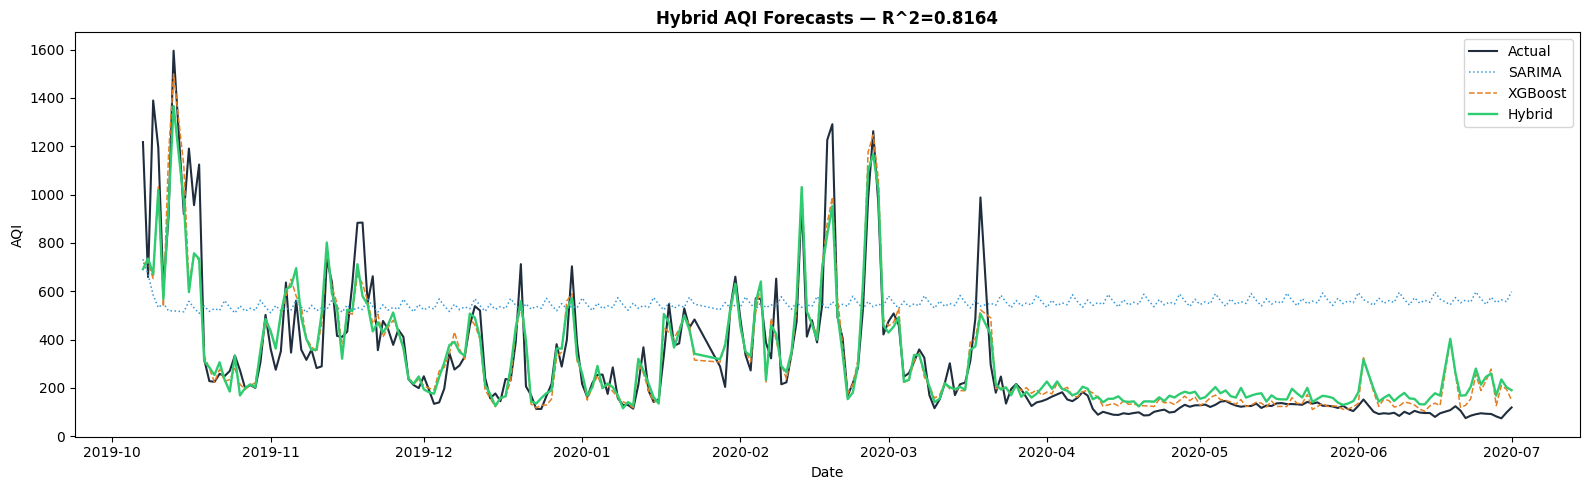

C:\Users\piyus\AppData\Local\Temp\ipykernel_25404\4006545278.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_hybrid, show=False)


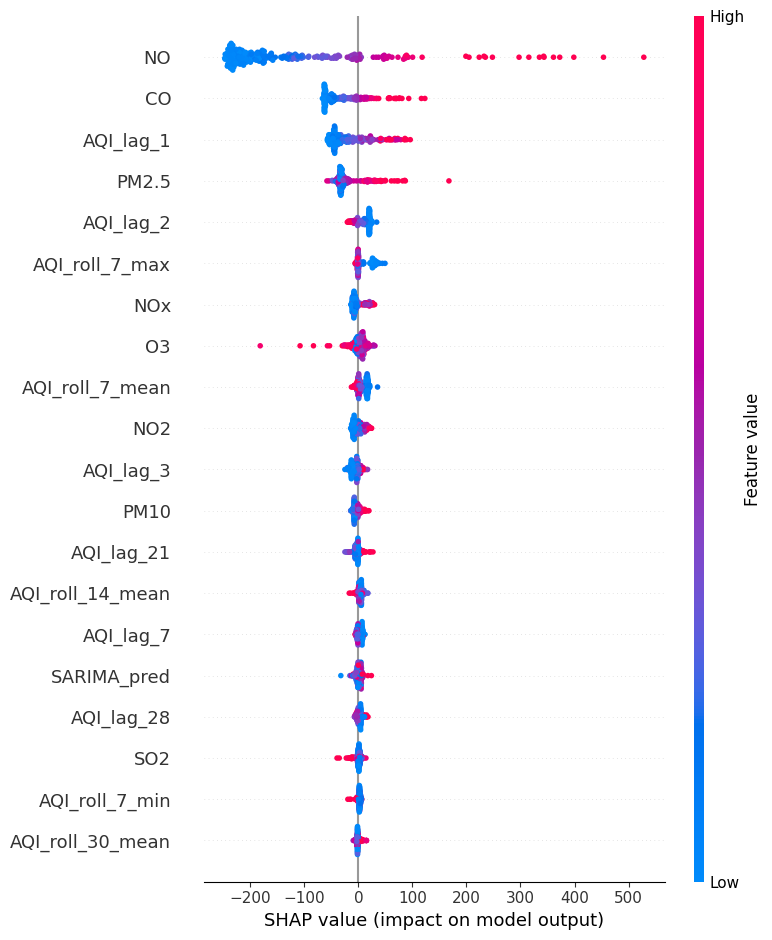

In [16]:
results = pd.DataFrame({
    'Model': ['SARIMA', 'XGBoost (Standalone)', 'Hybrid (SARIMA + XGBoost)'],
    'MAE': [sarima_mae, xgb_only_mae, hybrid_mae],
    'RMSE': [sarima_rmse, xgb_only_rmse, hybrid_rmse],
    'MAPE (%)': [sarima_mape, xgb_only_mape, hybrid_mape],
    'R2': [sarima_r2, xgb_only_r2, hybrid_r2]
}).set_index('Model')

print('MODEL COMPARISON — TEST SET')
display(results.round(4))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_test.index, y_test.values, label='Actual', color='#1f2d3d', linewidth=1.5)
ax.plot(y_test.index, sarima_pred_test, label='SARIMA', color='#3498db', linewidth=1.1, linestyle=':')
ax.plot(y_test.index, xgb_only_pred, label='XGBoost', color='#e67e22', linewidth=1.1, linestyle='--')
ax.plot(y_test.index, hybrid_pred, label='Hybrid', color='#2ecc71', linewidth=1.7)
ax.set_title(f'Hybrid AQI Forecasts — R^2={hybrid_r2:.4f}', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
plt.show()

explainer = shap.TreeExplainer(hybrid_model)
shap_values = explainer.shap_values(X_test_hybrid)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_hybrid, show=False)
plt.tight_layout()
plt.show()

## 9. Notes

- The SARIMA stage captures the seasonal baseline.
- The XGBoost stage learns nonlinear corrections from pollutants, weather, lags, and the SARIMA forecast.
- If you want, the next improvement is to tune the XGBoost hyperparameters on the training segment only.

## 10. Compact Results Table

In [ ]:
print(results.round(4).to_string())